In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)
from sklearn.svm import LinearSVC
import joblib
import os


df = pd.read_csv("/content/drive/MyDrive/TriageFlow/datasets/processed/cleaned_dataset.csv")

In [3]:
df.columns.tolist()

['subject', 'body', 'query_text', 'answer', 'queue', 'priority', 'type']

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16335 entries, 0 to 16334
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   subject     16335 non-null  object
 1   body        16335 non-null  object
 2   query_text  16335 non-null  object
 3   answer      16335 non-null  object
 4   queue       16335 non-null  object
 5   priority    16335 non-null  object
 6   type        16335 non-null  object
dtypes: object(7)
memory usage: 893.4+ KB


In [5]:
df.head(3)

,subject,body,query_text,answer,queue,priority,type
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Account Disruption Dear Customer Support Team,...","Thank you for reaching out, <name>. We are awa...",Technical Support,high,Incident
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Query About Smart Home System Integration Feat...,Thank you for your inquiry. Our products suppo...,Returns and Exchanges,medium,Request
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Inquiry Regarding Invoice Details Dear Custome...,We appreciate you reaching out with your billi...,Billing and Payments,low,Request


In [6]:
df['queue'].value_counts()

,count
queue,
Technical Support,4736
Product Support,3071
Customer Service,2410
IT Support,1942
Billing and Payments,1595
Returns and Exchanges,820
Service Outages and Maintenance,664
Sales and Pre-Sales,513
Human Resources,348


In [7]:
df["queue"].value_counts(normalize=True) * 100

,proportion
queue,
Technical Support,28.992960
Product Support,18.800122
Customer Service,14.753597
IT Support,11.888583
Billing and Payments,9.764310
Returns and Exchanges,5.019896
Service Outages and Maintenance,4.064891
Sales and Pre-Sales,3.140496
Human Resources,2.130395


In [8]:
X = df["query_text"]

y = df["queue"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
print("Training:", X_train.shape)

print("Testing :", X_test.shape)

Training: (13068,)
Testing : (3267,)


In [11]:
print(y_train.value_counts())

queue
Technical Support                  3789
Product Support                    2457
Customer Service                   1928
IT Support                         1554
Billing and Payments               1276
Returns and Exchanges               656
Service Outages and Maintenance     531
Sales and Pre-Sales                 410
Human Resources                     278
General Inquiry                     189
Name: count, dtype: int64


In [12]:
print(y_test.value_counts())

queue
Technical Support                  947
Product Support                    614
Customer Service                   482
IT Support                         388
Billing and Payments               319
Returns and Exchanges              164
Service Outages and Maintenance    133
Sales and Pre-Sales                103
Human Resources                     70
General Inquiry                     47
Name: count, dtype: int64


In [13]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

In [14]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [15]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)
print(type(X_train_tfidf))

(13068, 10000)
(3267, 10000)
<class 'scipy.sparse._csr.csr_matrix'>


In [16]:
classifier = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

classifier.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42)

In [17]:
#predicting on test set
y_pred = classifier.predict(X_test_tfidf)

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.4983164983164983


In [19]:
print(classification_report(y_test, y_pred))

                                 precision    recall  f1-score   support

           Billing and Payments       0.80      0.75      0.77       319
               Customer Service       0.44      0.40      0.42       482
                General Inquiry       0.33      0.64      0.43        47
                Human Resources       0.42      0.67      0.52        70
                     IT Support       0.39      0.47      0.43       388
                Product Support       0.49      0.40      0.44       614
          Returns and Exchanges       0.37      0.52      0.43       164
            Sales and Pre-Sales       0.32      0.65      0.43       103
Service Outages and Maintenance       0.54      0.78      0.64       133
              Technical Support       0.61      0.46      0.52       947

                       accuracy                           0.50      3267
                      macro avg       0.47      0.57      0.50      3267
                   weighted avg       0.52      0

49\% accuracy is too low for the project, thus logistic regression model is rejected.

In [20]:
classifier = LinearSVC(
    class_weight="balanced",
    random_state=42
)

In [21]:
classifier.fit(X_train_tfidf, y_train)

LinearSVC(class_weight='balanced', random_state=42)

In [22]:
y_pred = classifier.predict(X_test_tfidf)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6137128864401592
                                 precision    recall  f1-score   support

           Billing and Payments       0.82      0.83      0.82       319
               Customer Service       0.56      0.56      0.56       482
                General Inquiry       0.70      0.66      0.68        47
                Human Resources       0.68      0.73      0.70        70
                     IT Support       0.50      0.56      0.53       388
                Product Support       0.59      0.53      0.56       614
          Returns and Exchanges       0.53      0.59      0.56       164
            Sales and Pre-Sales       0.48      0.65      0.55       103
Service Outages and Maintenance       0.66      0.77      0.71       133
              Technical Support       0.66      0.62      0.64       947

                       accuracy                           0.61      3267
                      macro avg       0.62      0.65      0.63      3267
                   w

In [24]:
joblib.dump(classifier, "queue_classifier.pkl")

['queue_classifier.pkl']

In [25]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [26]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [27]:
import sklearn
print(sklearn.__version__)
print(joblib.__version__)

1.6.1
1.5.3


I evaluated models including Logistic Regression and LinearSVC. LinearSVC achieved the highest test accuracy (about 61.4%), so I selected it for deployment. Since LinearSVC does not provide calibrated probabilities, I used its decision score as a confidence indicator.

In [28]:
import torch
import sklearn

print("Torch:", torch.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Pandas:", pd.__version__)

Torch: 2.11.0+cpu
Scikit-learn: 1.6.1
Pandas: 2.2.2


In [29]:
classifier.score(X_test_tfidf, y_test)

0.6137128864401592

In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.6137128864401592


In [31]:
from sklearn.metrics import precision_score

precision_score(y_test, y_pred, average="weighted")

0.6169029446616179

In [32]:
from sklearn.metrics import recall_score

recall_score(y_test, y_pred, average="weighted")

0.6137128864401592

In [33]:
from sklearn.metrics import f1_score

f1_score(y_test, y_pred, average="weighted")

0.6138592170532176

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                                 precision    recall  f1-score   support

           Billing and Payments       0.82      0.83      0.82       319
               Customer Service       0.56      0.56      0.56       482
                General Inquiry       0.70      0.66      0.68        47
                Human Resources       0.68      0.73      0.70        70
                     IT Support       0.50      0.56      0.53       388
                Product Support       0.59      0.53      0.56       614
          Returns and Exchanges       0.53      0.59      0.56       164
            Sales and Pre-Sales       0.48      0.65      0.55       103
Service Outages and Maintenance       0.66      0.77      0.71       133
              Technical Support       0.66      0.62      0.64       947

                       accuracy                           0.61      3267
                      macro avg       0.62      0.65      0.63      3267
                   weighted avg       0.62      0

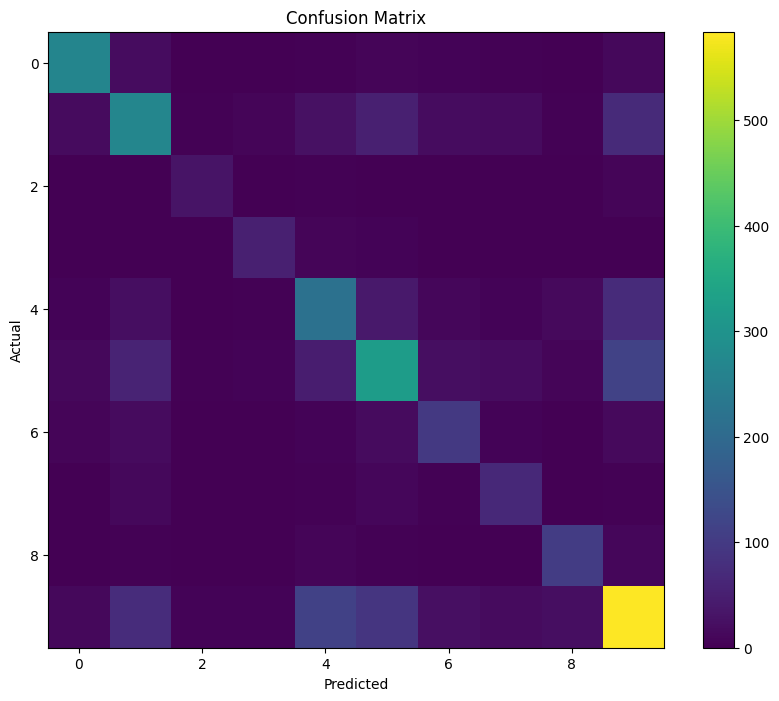

In [35]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()